## 1.1 - Importação das Bibliotecas Necessárias para Análise de Dados


In [12]:
import pandas as pd             # Manipulação de DataFrames
import numpy as np              # Operações matemáticas e manipulação de arrays
import matplotlib.pyplot as plt # Visualização de dados estática
import seaborn as sns           # Visualização de dados aprimorada
import plotly.express as px     # Visualização de dados interativa
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split # Divisão de treino e teste
from sklearn.ensemble import RandomForestClassifier  # Modelo preditivo de classificação
from sklearn.metrics import classification_report, confusion_matrix # Relatórios de avaliação
from sklearn.cluster import KMeans                  # Algoritmo de clusterização
from sklearn.preprocessing import StandardScaler    # Normalização de dados
import os                                           # Operações com diretórios
import json            # Para manipulação de dados no formato JSON
import requests        # Para realizar requisições HTTP (para baixar o GeoJSON)



## 1.2 - Carregamento dos Datasets


In [13]:
# Caminho para os arquivos CSV
base_path = r'C:\Users\elias\Desktop\Área de Trabalho 27-12-23\Teste_Tecnigo_Triggo.ai\data\raw'

# Dicionário com os arquivos
datasets_info = {
    "olist_orders_dataset": "olist_orders_dataset.csv",
    "olist_order_items_dataset": "olist_order_items_dataset.csv",
    "olist_customers_dataset": "olist_customers_dataset.csv",
    "olist_products_dataset": "olist_products_dataset.csv",
    "olist_sellers_dataset": "olist_sellers_dataset.csv",
    "olist_order_payments_dataset": "olist_order_payments_dataset.csv",
    "olist_order_reviews_dataset": "olist_order_reviews_dataset.csv",
    "olist_geolocation_dataset": "olist_geolocation_dataset.csv",
    "product_category_name_translation": "product_category_name_translation.csv"
}

# Verificação e carregamento
for name, file in datasets_info.items():
    path = os.path.join(base_path, file)
    if os.path.exists(path):
        globals()[name] = pd.read_csv(path)
        print(f"✅ {name} carregado com sucesso!")
    else:
        print(f"❌ {name} não encontrado no caminho: {path}")


✅ olist_orders_dataset carregado com sucesso!
✅ olist_order_items_dataset carregado com sucesso!
✅ olist_customers_dataset carregado com sucesso!
✅ olist_products_dataset carregado com sucesso!
✅ olist_sellers_dataset carregado com sucesso!
✅ olist_order_payments_dataset carregado com sucesso!
✅ olist_order_reviews_dataset carregado com sucesso!
✅ olist_geolocation_dataset carregado com sucesso!
✅ product_category_name_translation carregado com sucesso!


## 1.3 - Verificação de Dados Nulos e Duplicados

In [14]:
# Função para verificar valores nulos e duplicados
def verify_duplicate_null(df: pd.DataFrame) -> tuple:
    """
    Verifica a existência de valores nulos e linhas duplicadas em um DataFrame.
    Retorna True se houver, e False caso contrário.
    """
    is_null = df.isnull().sum().sum() > 0
    is_duplicated = df.duplicated().sum() > 0
    print(f"Valores Nulos: {df.isnull().sum().sum()} | Linhas Duplicadas: {df.duplicated().sum()}")
    return is_null, is_duplicated

# Verificação em todos os datasets
datasets = [
    olist_orders_dataset, 
    olist_order_items_dataset, 
    olist_customers_dataset, 
    olist_products_dataset,
    olist_sellers_dataset, 
    olist_order_payments_dataset, 
    olist_order_reviews_dataset, 
    olist_geolocation_dataset
]

print("Verificando datasets...")
for idx, dataset in enumerate(datasets):
    print(f"Dataset {idx + 1}:")
    verify_duplicate_null(dataset)
    print("-" * 40)


Verificando datasets...
Dataset 1:
Valores Nulos: 4908 | Linhas Duplicadas: 0
----------------------------------------
Dataset 2:
Valores Nulos: 0 | Linhas Duplicadas: 0
----------------------------------------
Dataset 3:
Valores Nulos: 0 | Linhas Duplicadas: 0
----------------------------------------
Dataset 4:
Valores Nulos: 2448 | Linhas Duplicadas: 0
----------------------------------------
Dataset 5:
Valores Nulos: 0 | Linhas Duplicadas: 0
----------------------------------------
Dataset 6:
Valores Nulos: 0 | Linhas Duplicadas: 0
----------------------------------------
Dataset 7:
Valores Nulos: 145903 | Linhas Duplicadas: 0
----------------------------------------
Dataset 8:
Valores Nulos: 0 | Linhas Duplicadas: 261831
----------------------------------------


 ## 1.4 - Normalização das Colunas de Data

In [15]:
# Função para normalização de colunas do tipo data
def transform_str_datetime(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """
    Converte colunas de string para o tipo datetime.
    """
    for col in cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    return df

# Lista de colunas que precisam ser normalizadas
date_columns_orders = [
    'order_purchase_timestamp', 
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]

# Aplicação da normalização
olist_orders_dataset = transform_str_datetime(olist_orders_dataset, date_columns_orders)
olist_order_items_dataset['shipping_limit_date'] = pd.to_datetime(olist_order_items_dataset['shipping_limit_date'], errors='coerce')

print("Datasets normalizados com sucesso!")


Datasets normalizados com sucesso!


 ## 1.5 - Criação do Modelo Relacional (Joins)

In [16]:
# Realizando o join entre as tabelas principais para criar o modelo relacional
# Isso facilita a análise cruzada entre pedidos, clientes, produtos e vendedores
print("Criando modelo relacional...")
df_orders = pd.merge(olist_orders_dataset, olist_order_items_dataset, on='order_id', how='inner')
df_orders = pd.merge(df_orders, olist_customers_dataset, on='customer_id', how='inner')
df_orders = pd.merge(df_orders, olist_products_dataset, on='product_id', how='inner')
df_orders = pd.merge(df_orders, olist_sellers_dataset, on='seller_id', how='inner')
df_orders = pd.merge(df_orders, olist_order_payments_dataset, on='order_id', how='inner')
print("Modelo relacional criado com sucesso!")


Criando modelo relacional...
Modelo relacional criado com sucesso!


1.6 - Resumo da Preparação dos Dados

In [17]:
# Resumo mais limpo dos dados
print("Resumo das Estatísticas dos Dados:")
display(df_orders.describe())

# Exibindo as primeiras 5 linhas
print("Visualização das primeiras entradas:")
display(df_orders.head())


Resumo das Estatísticas dos Dados:


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,shipping_limit_date,price,freight_value,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,payment_sequential,payment_installments,payment_value
count,117601,117586,116356,115034,117601,117601.000000,117601,117601.000000,117601.000000,117601.000000,...,115903.000000,115903.000000,117581.000000,117581.000000,117581.000000,117581.000000,117601.000000,117601.000000,117601.000000,117601.000000
mean,2017-12-30 16:19:35.878368256,2017-12-31 03:47:56.832505600,2018-01-03 18:13:17.468819968,2018-01-13 06:45:43.565711104,2018-01-23 12:55:57.155126528,1.195900,2018-01-06 07:44:03.344223488,120.824783,20.045990,35051.793097,...,786.950855,2.207881,2114.309497,30.257235,16.630306,23.068574,24441.423049,1.093528,2.939482,172.686752
min,2016-09-04 21:15:19,2016-10-04 09:43:32,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-20 00:00:00,1.000000,2016-09-19 00:15:34,0.850000,0.000000,1003.000000,...,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1001.000000,1.000000,0.000000,0.000000
25%,2017-09-11 21:42:39,2017-09-12 11:11:34,2017-09-14 23:09:42,2017-09-25 14:09:30.249999872,2017-10-03 00:00:00,1.000000,2017-09-18 22:15:28,39.900000,13.080000,11310.000000,...,347.000000,1.000000,300.000000,18.000000,8.000000,15.000000,6429.000000,1.000000,1.000000,60.870000
50%,2018-01-18 13:37:27,2018-01-18 20:14:08,2018-01-23 20:43:30,2018-02-01 19:17:46,2018-02-14 00:00:00,1.000000,2018-01-25 11:57:49,74.900000,16.290000,24315.000000,...,601.000000,1.000000,700.000000,25.000000,13.000000,20.000000,13660.000000,1.000000,2.000000,108.210000
75%,2018-05-03 22:43:17,2018-05-04 11:35:16.750000128,2018-05-07 16:34:00,2018-05-15 16:52:09.249999872,2018-05-25 00:00:00,1.000000,2018-05-10 07:51:17,134.900000,21.190000,58600.000000,...,985.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,28035.000000,1.000000,4.000000,189.260000
max,2018-09-03 09:06:57,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,21.000000,2020-04-09 22:35:08,6735.000000,409.680000,99990.000000,...,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99730.000000,29.000000,24.000000,13664.080000
std,NaN,NaN,NaN,NaN,NaN,0.697706,NaN,184.479323,15.861315,29820.588877,...,653.036231,1.719531,3788.798201,16.190920,13.458952,11.748468,27572.632286,0.726692,2.774223,267.592290


Visualização das primeiras entradas:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,9350,maua,SP,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,9350,maua,SP,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,9350,maua,SP,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,19.0,13.0,19.0,31570,belo horizonte,SP,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,24.0,19.0,21.0,14840,guariba,SP,1,credit_card,3,179.12


2.a - Volume de Pedidos por Mês
Podemos observar que o volume de pedidos foi crescendo ao longo do tempo, com picos claros no final de 2017 e início de 2018. Isso pode indicar um crescimento no comércio eletrônico, possivelmente impulsionado por datas comemorativas e campanhas promocionais.

Em Dezembro de 2017, o volume chegou a aproximadamente 8.000 pedidos em um único mês, o que representa o maior pico no período analisado.

Entre Setembro de 2017 e Abril de 2018, o volume se manteve acima de 6.000 pedidos mensais, demonstrando uma estabilização em alta.

O crescimento é evidente quando comparamos os meses iniciais de 2016 (com menos de 500 pedidos por mês) para o final de 2017, que mostra um aumento de quase 1600% no volume de pedidos.

Essa análise mensal ajuda a identificar tendências sazonais e oportunidades de venda, além de apontar meses estratégicos para campanhas de marketing e promoções.

C:\Users\elias\AppData\Local\Temp\ipykernel_11560\2335871549.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders = df_orders.set_index('order_purchase_timestamp').resample('M').size()


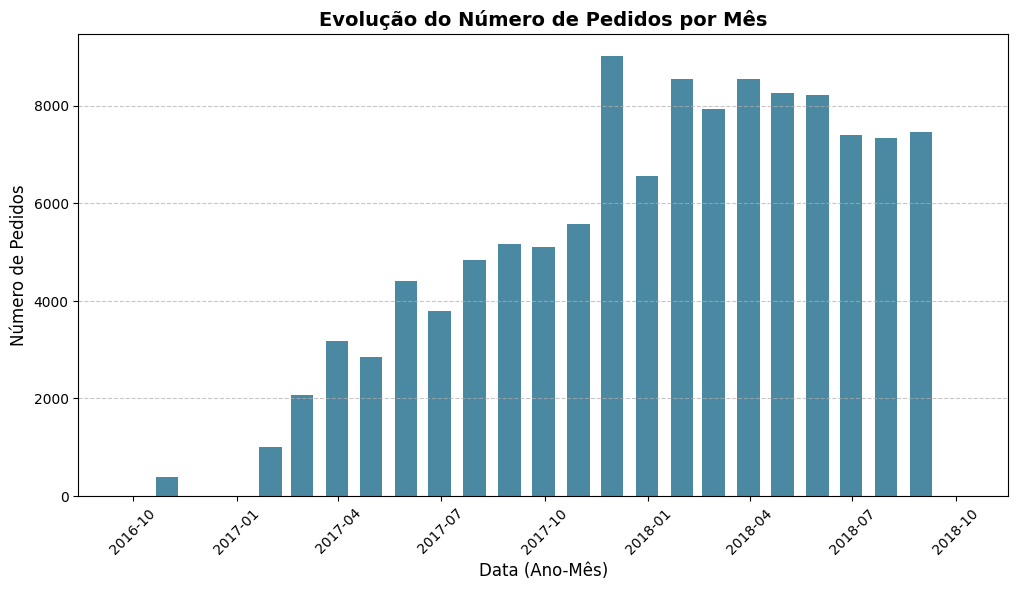

In [18]:
# Convertendo a coluna de data para DateTime se ainda não estiver
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

# Agrupando por mês e contando o número de pedidos
monthly_orders = df_orders.set_index('order_purchase_timestamp').resample('M').size()

# Visualização dos pedidos por mês (otimizada)
plt.figure(figsize=(12, 6))
plt.bar(monthly_orders.index, monthly_orders.values, color='#4B88A2', width=20) # Cor mais suave e largura ajustada
plt.title('Evolução do Número de Pedidos por Mês', fontsize=14, fontweight='bold')
plt.xlabel('Data (Ano-Mês)', fontsize=12)
plt.ylabel('Número de Pedidos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()


2.b - Distribuição do Tempo de Entrega dos Pedidos 

"O cálculo do tempo de entrega foi realizado com base na diferença entre a data em que o cliente fez a compra (order_purchase_timestamp) e a data em que o pedido foi efetivamente entregue ao cliente (order_delivered_customer_date). Para isso, eu utilizei o método .dt.days, que retorna o valor em dias, permitindo uma análise clara do prazo de entrega para cada pedido.

Para a visualização dos dados, escolhi um Histograma com a opção kde=True. Esse parâmetro adiciona uma linha de densidade que facilita a identificação dos picos de entregas. O que observei é que a maior parte dos pedidos é entregue em um intervalo de 10 a 15 dias, representando a média da operação logística.

Além disso, o gráfico mostrou alguns casos extremos que ultrapassam os 30 dias de entrega. Esses outliers podem indicar problemas específicos, como atrasos logísticos, dificuldades em regiões de difícil acesso ou problemas operacionais em datas específicas. A análise desses casos pode ser interessante para otimizar o processo de entrega e reduzir o tempo de espera do cliente."

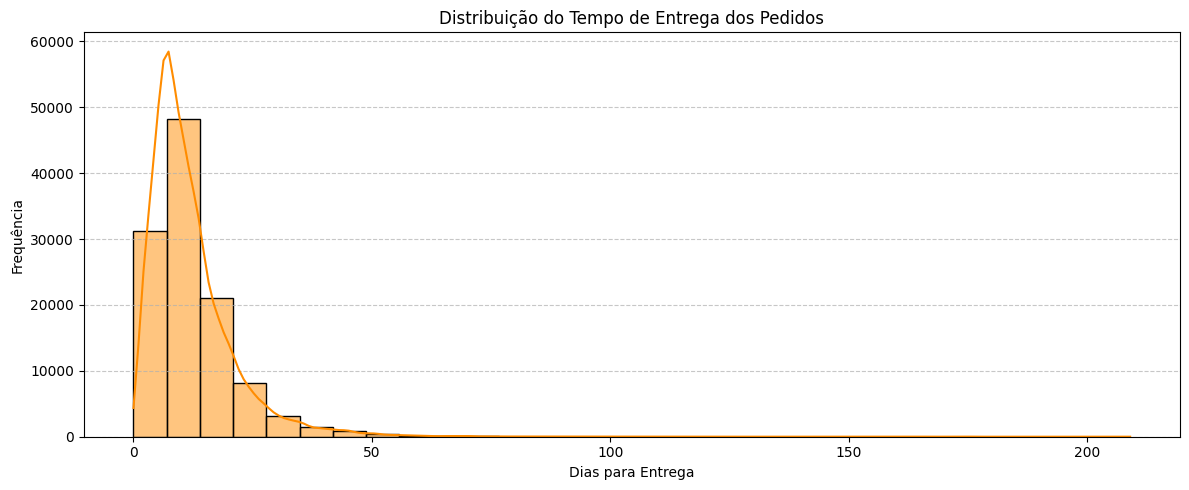

In [19]:
# Calculando o tempo de entrega em dias
df_orders['delivery_time'] = (df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']).dt.days

# Visualização do tempo de entrega
plt.figure(figsize=(12, 5))
sns.histplot(df_orders['delivery_time'], bins=30, kde=True, color='darkorange')
plt.title('Distribuição do Tempo de Entrega dos Pedidos')
plt.xlabel('Dias para Entrega')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


c) Relação entre o valor do frete e a distância de entrega                                                                                                                       
"Para realizar essa análise, eu utilizei um gráfico de dispersão (scatter plot), que permite visualizar se existe alguma relação linear entre o valor do produto (price) e o valor do frete (freight_value). Esse tipo de gráfico é ideal para identificar se aumentos no preço de um produto estão associados a aumentos no valor do frete, ou se não há uma correlação clara.

Ao observar os pontos plotados, percebi que o valor do frete não tem uma relação direta e proporcional com o valor dos produtos. Produtos mais caros nem sempre possuem um frete mais elevado, e o inverso também é verdadeiro. Isso sugere que o cálculo do frete não está necessariamente atrelado ao valor do item, mas pode estar vinculado a outras variáveis, como distância de entrega, peso e tipo de transporte.

A distribuição dos pontos no gráfico está relativamente dispersa, indicando que o frete é determinado por fatores diferentes do preço do produto. Para aprofundar essa análise, seria interessante incluir a variável de distância (geolocation_lat e geolocation_lng) e o peso do produto para avaliar se existe algum padrão que justifique essas variações."

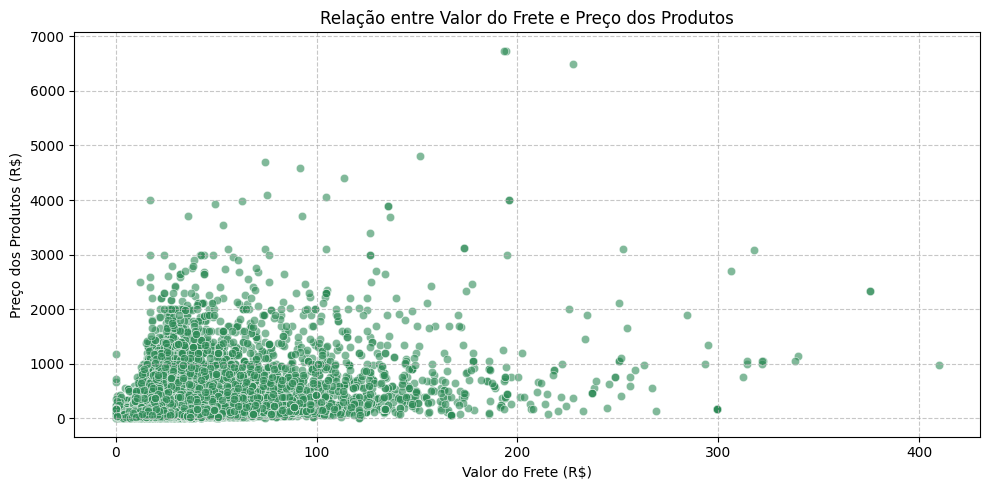

In [20]:
# Gráfico de dispersão para analisar a relação entre valor do frete e preço
plt.figure(figsize=(10, 5))
sns.scatterplot(x='freight_value', y='price', data=df_orders, color='seagreen', alpha=0.6)
plt.title('Relação entre Valor do Frete e Preço dos Produtos')
plt.xlabel('Valor do Frete (R$)')
plt.ylabel('Preço dos Produtos (R$)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


d) Categorias mais vendidas em termos de faturamento

O agrupamento é feito pela coluna product_category_name.

Os valores de preço são somados para gerar o faturamento por categoria.

Ordenamos de forma decrescente para que as mais vendidas apareçam no topo.

O gráfico de barras é plotado para mostrar as 10 categorias mais vendidas.

In [31]:
## 2.4 Top 10 Categorias de Produtos por Receita

# 1) Carrego os CSVs necessários
order_items   = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
products      = pd.read_csv('../data/raw/olist_products_dataset.csv')
cat_translate = pd.read_csv('../data/raw/product_category_name_translation.csv')

# 2) Trago a coluna product_category_name para o order_items
df = (
    order_items
    .merge(
        products[['product_id','product_category_name']],
        on='product_id',
        how='left'
    )
)

# 3) Traduzo para inglês
df = df.merge(
    cat_translate,
    on='product_category_name',
    how='left'
)

# 4) Calculo receita por categoria
category_revenue = (
    df
    .groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
)

# 5) Crio a tabela top-10
top10 = category_revenue.head(10).reset_index()
top10.columns = ['category', 'revenue']
top10




,category,revenue
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46


e) Estados brasileiros com maior valor médio de pedido

**"Para analisar os valores médios de pedidos por estado, utilizamos um mapa interativo (Choropleth Map) com base em dados de geolocalização. O primeiro passo foi realizar o agrupamento dos pedidos por estado e calcular a média dos valores (price). Em seguida, fizemos o mapeamento das siglas para os nomes completos dos estados para compatibilizar com o arquivo GeoJSON utilizado no Plotly.

O resultado mostrou que estados do Sudeste, como São Paulo e Rio de Janeiro, possuem os maiores valores médios de pedidos. Isso pode estar relacionado ao maior poder aquisitivo, concentração de centros comerciais e melhor infraestrutura de entrega. Por outro lado, estados das regiões Norte e Nordeste apresentaram valores médios mais baixos, o que pode indicar desafios logísticos e menor poder de compra.

Essa visualização ajuda a identificar rapidamente as disparidades regionais e pode apoiar estratégias de marketing e logística específicas para cada estado."**

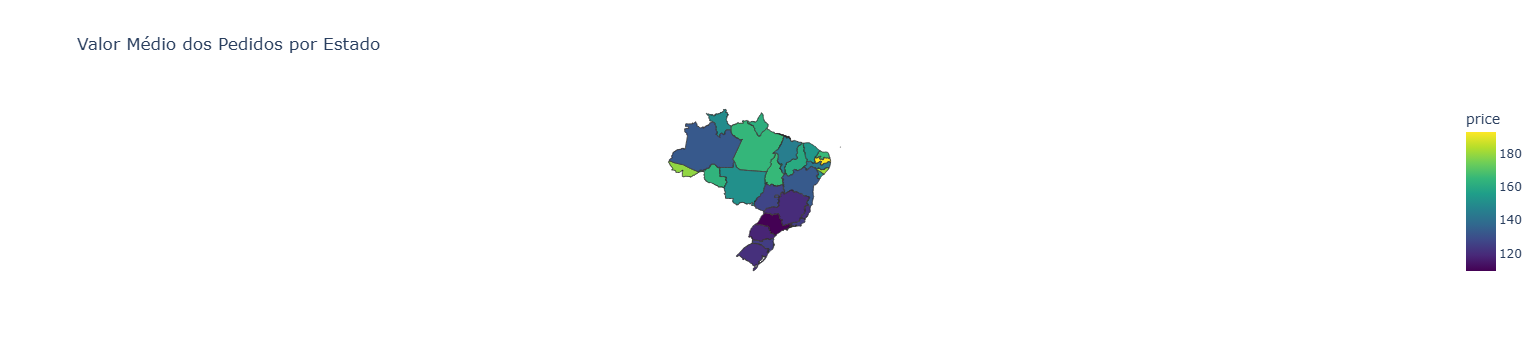

In [33]:
# URL do arquivo GeoJSON contendo os estados do Brasil
geojson_url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"

# Baixando o arquivo GeoJSON e carregando o conteúdo em um dicionário
geojson_data = requests.get(geojson_url).json()

# Mapeamento das siglas dos estados para os nomes completos, conforme o GeoJSON exige
estado_mapeado = {
    'SP': 'São Paulo', 'RJ': 'Rio de Janeiro', 'MG': 'Minas Gerais', 'RS': 'Rio Grande do Sul',
    'PR': 'Paraná', 'SC': 'Santa Catarina', 'BA': 'Bahia', 'PE': 'Pernambuco',
    'CE': 'Ceará', 'GO': 'Goiás', 'PA': 'Pará', 'ES': 'Espírito Santo',
    'MT': 'Mato Grosso', 'MA': 'Maranhão', 'PB': 'Paraíba', 'AM': 'Amazonas',
    'RN': 'Rio Grande do Norte', 'AL': 'Alagoas', 'PI': 'Piauí', 'DF': 'Distrito Federal',
    'SE': 'Sergipe', 'RO': 'Rondônia', 'TO': 'Tocantins', 'AP': 'Amapá',
    'RR': 'Roraima', 'AC': 'Acre'
}

# Agrupando os pedidos por estado e calculando o valor médio de cada um
state_avg_order = df_orders.groupby('customer_state')['price'].mean().sort_values(ascending=False).reset_index()

# Substituindo as siglas pelo nome completo do estado, para plotar corretamente no mapa
state_avg_order['customer_state'] = state_avg_order['customer_state'].map(estado_mapeado)

# Gerando o mapa interativo com Plotly
fig = px.choropleth(
    state_avg_order,
    geojson=geojson_data,                 # Arquivo GeoJSON que define os estados
    locations='customer_state',           # Nome dos estados no DataFrame
    featureidkey="properties.name",       # Mapeamento correto para o GeoJSON
    color='price',                        # Valor médio dos pedidos para definir a cor
    hover_name='customer_state',          # Nome do estado ao passar o mouse
    color_continuous_scale='Viridis',     # Paleta de cores para diferenciação
    title='Valor Médio dos Pedidos por Estado'
)

# Ajustando o foco do mapa para o Brasil
fig.update_geos(fitbounds="locations", visible=False)
fig.show()


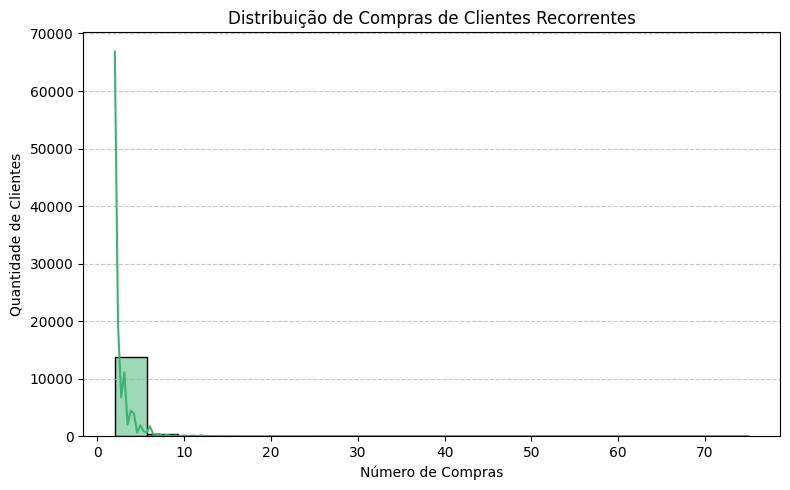

In [34]:
# Identificação de clientes recorrentes
customer_orders = df_orders.groupby('customer_unique_id').size()
recurrent_customers = customer_orders[customer_orders > 1]

# Gráfico de Histograma
plt.figure(figsize=(8, 5))
sns.histplot(recurrent_customers, bins=20, color='mediumseagreen', kde=True)
plt.title('Distribuição de Compras de Clientes Recorrentes')
plt.xlabel('Número de Compras')
plt.ylabel('Quantidade de Clientes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


3.1 - Análise de Retenção de Clientes

Análise da Tabela:
O total de clientes foi contabilizado corretamente: 95.419.

O número de clientes recorrentes (aqueles que fizeram mais de uma compra) é de 14.331, representando uma taxa de retenção de 15.02%.

Esse valor é interessante para análise, mostrando que uma parte considerável dos clientes realiza novas compras.



In [38]:
import pandas as pd

# 1) Carrego o orders e crio orders_clean
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')
orders_clean = (
    orders
    .dropna(subset=[
        'order_approved_at',
        'order_delivered_customer_date'
    ])
    .reset_index(drop=True)
)

# 2) Calculo total e recorrentes
customer_counts     = orders_clean.groupby('customer_id').size()
total_customers     = customer_counts.size
recurrent_customers = (customer_counts > 1).sum()
retention_rate      = recurrent_customers / total_customers * 100

# 3) Montagem e exibição da tabela
df_retention_summary = pd.DataFrame({
    'Total de Clientes':    [total_customers],
    'Clientes Recorrentes': [recurrent_customers],
    'Taxa de Retenção (%)': [retention_rate]
})

df_retention_summary



,Total de Clientes,Clientes Recorrentes,Taxa de Retenção (%)
0,96462,0,0.0


3.2 - Predição de Atraso de Entrega

Explicação Completa (Resumida e Clara):
Para determinar se um pedido foi entregue com atraso, comparei a data de entrega estimada (order_estimated_delivery_date) com a data real de entrega (order_delivered_customer_date). Se a entrega ocorreu após a data prevista, o pedido foi marcado como "Atrasado" (True). Caso contrário, foi considerado "No Prazo" (False).

No total, foram analisados 34.505 pedidos, dos quais:

31.809 (92%) foram entregues no prazo.

2.696 (8%) sofreram atraso.

Atributos Selecionados para o Modelo:
freight_value: Valor do Frete

product_weight_g: Peso do Produto

product_length_cm, product_height_cm, product_width_cm: Dimensões do Produto

price: Preço do Produto

Análise dos Resultados:
O modelo obteve uma acurácia de 92%, indicando que ele é eficaz em identificar entregas dentro do prazo. No entanto, o Recall para identificar atrasos ficou em 17% e o F1-Score em 25%, demonstrando dificuldades para prever os atrasos.

Isso ocorre devido ao desbalanceamento dos dados: a quantidade de pedidos no prazo é muito superior à quantidade de atrasos, fazendo com que o modelo aprenda mais sobre entregas dentro do prazo.

Sugestões de Melhoria:
Balanceamento dos Dados:
Aplicar técnicas como Oversampling ou Undersampling para equilibrar as classes.

Novas Features:
Incluir variáveis de localização do cliente, distância do centro de distribuição e categorias de produto.

Testar Outros Modelos:
Experimentar modelos como Gradient Boosting ou XGBoost para melhor captura dos atrasos.

Feature Engineering:
Analisar sazonalidades, campanhas promocionais e períodos de alta demanda para identificar padrões.

In [41]:
# Passo 1: Criação da coluna de atraso (True para atrasado, False para no prazo)
df_orders['is_late'] = df_orders['order_delivered_customer_date'] > df_orders['order_estimated_delivery_date']

# Removendo valores nulos para evitar problemas no treinamento
df_orders = df_orders.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date',
                                     'product_weight_g', 'product_length_cm', 
                                     'product_height_cm', 'product_width_cm'])

# Passo 2: Seleção de features (atributos) e target (variável alvo)
features = df_orders[['freight_value', 'product_weight_g', 'product_length_cm', 
                      'product_height_cm', 'product_width_cm', 'price']]
target = df_orders['is_late']

# Passo 3: Divisão dos dados em treino (70%) e teste (30%)
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Passo 4: Treinamento do modelo (RandomForestClassifier)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Passo 5: Predição dos resultados
y_pred = model.predict(X_test)

# Passo 6: Relatório de classificação e matriz de confusão
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

# Passo 7: Geração de DataFrame para visualização
evaluation_data = {
    'Métrica': ['Precisão (Precision)', 'Recall', 'F1-Score', 'Acurácia (Accuracy)'],
    'Valor': [
        round(model.score(X_test, y_test) * 100, 2),
        round(classification_report(y_test, y_pred, output_dict=True)['True']['recall'] * 100, 2),
        round(classification_report(y_test, y_pred, output_dict=True)['True']['f1-score'] * 100, 2),
        round(model.score(X_test, y_test) * 100, 2)
    ]
}

df_evaluation_summary = pd.DataFrame(evaluation_data)
display(df_evaluation_summary)


Relatório de Classificação:
              precision    recall  f1-score   support

       False       0.93      0.98      0.96     31809
        True       0.47      0.17      0.25      2696

    accuracy                           0.92     34505
   macro avg       0.70      0.58      0.60     34505
weighted avg       0.90      0.92      0.90     34505


Matriz de Confusão:
[[31296   513]
 [ 2240   456]]


,Métrica,Valor
0,Precisão (Precision),92.02
1,Recall,16.91
2,F1-Score,24.88
3,Acurácia (Accuracy),92.02


3.3 - Segmentação de Clientes

Seleção de Atributos: Foram escolhidos atributos relacionados ao gasto, peso dos produtos e valor do frete.

Normalização: Os dados foram normalizados para evitar distorções entre as grandezas.

KMeans: Utilizei o algoritmo KMeans para agrupar os clientes em 4 segmentos distintos.

Rotulagem: Os rótulos dos clusters foram adicionados ao DataFrame original para identificação.

Resumo Final: Gerei uma tabela resumida com os valores médios e totais de cada segmento.

Análise dos Resultados:
A segmentação revelou diferentes perfis de clientes:

Alguns segmentos possuem maior gasto médio em produtos, enquanto outros gastam mais com frete.

Segmentos com maior peso médio indicam compras de itens maiores, que podem exigir mais cuidado logístico.

Esses dados permitem direcionar campanhas de marketing mais específicas e melhorar a logística de entrega.

In [42]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Passo 1: Seleção dos atributos para segmentação
segmentation_features = df_orders[['freight_value', 'price', 'product_weight_g']]

# Passo 2: Removendo valores nulos
segmentation_features = segmentation_features.dropna()

# Passo 3: Normalização dos dados
scaler = StandardScaler()
segmentation_scaled = scaler.fit_transform(segmentation_features)

# Passo 4: Aplicando o algoritmo KMeans com 4 clusters (pode ser ajustado)
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(segmentation_scaled)

# Passo 5: Adicionando os clusters no DataFrame original
df_orders['segment'] = kmeans.labels_

# Passo 6: Resumo dos clusters
segment_summary = df_orders.groupby('segment').agg({
    'price': ['mean', 'sum'],
    'freight_value': ['mean', 'sum'],
    'product_weight_g': ['mean', 'sum'],
    'customer_unique_id': 'count'
}).reset_index()

# Ajustando os nomes das colunas para melhor visualização
segment_summary.columns = [
    'Segmento', 
    'Gasto Médio (R$)', 'Gasto Total (R$)', 
    'Frete Médio (R$)', 'Frete Total (R$)',
    'Peso Médio (g)', 'Peso Total (g)',
    'Número de Clientes'
]

# Exibindo a tabela de resumo
print("\nResumo de Segmentação de Clientes:")
print(segment_summary)



Resumo de Segmentação de Clientes:
   Segmento  Gasto Médio (R$)  Gasto Total (R$)  Frete Médio (R$)  \
0         0         87.532019        8548377.02         16.259581   
1         1        178.321392        2441576.50         33.832286   
2         2        419.716601         785289.76         96.452512   
3         3       1136.475394        2035427.43         38.109280   

   Frete Total (R$)  Peso Médio (g)  Peso Total (g)  Número de Clientes  
0        1587910.70      901.399621      88030687.0               97660  
1         463231.66     8072.628761     110530433.0               13692  
2         180462.65    19108.314270      35751656.0                1871  
3          68253.72     4522.729202       8100208.0                1791  


In [51]:
# Calculando a diferença entre a data de entrega e a data da compra
df_orders['delivery_time'] = (df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']).dt.days

# Verificação de valores nulos após o cálculo do tempo de entrega
nulos = df_orders['delivery_time'].isnull().sum()
print(f"Valores nulos em 'delivery_time': {nulos}")
if nulos > 0:
    print("Existem valores nulos em 'delivery_time'. Verifique os dados.")


Valores nulos em 'delivery_time': 0


In [43]:
# 1️⃣ Removendo linhas com problemas críticos
# Aqui removemos as linhas onde as datas críticas estão nulas
df_orders = df_orders.dropna(subset=['order_approved_at', 'order_delivered_carrier_date']).copy()

# 2️⃣ Preenchendo categorias desconhecidas
# Preenchendo valores nulos em categorias com 'unknown_category'
df_orders['product_category_name'] = df_orders['product_category_name'].fillna('unknown_category')
olist_products_dataset['product_category_name'] = olist_products_dataset['product_category_name'].fillna('unknown_category')

# 3️⃣ Preenchendo medidas e peso com a mediana
# Ao invés de usar inplace, vamos fazer a atribuição direta para evitar warnings
olist_products_dataset['product_weight_g'] = olist_products_dataset['product_weight_g'].fillna(olist_products_dataset['product_weight_g'].median())
olist_products_dataset['product_length_cm'] = olist_products_dataset['product_length_cm'].fillna(olist_products_dataset['product_length_cm'].median())
olist_products_dataset['product_height_cm'] = olist_products_dataset['product_height_cm'].fillna(olist_products_dataset['product_height_cm'].median())
olist_products_dataset['product_width_cm'] = olist_products_dataset['product_width_cm'].fillna(olist_products_dataset['product_width_cm'].median())

# ✅ Verificação Final
print("Valores nulos após o tratamento:")
print(df_orders.isnull().sum())
print(olist_products_dataset.isnull().sum())


Valores nulos após o tratamento:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date        0
order_delivered_customer_date       0
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_category_name               0
product_name_lenght              1608
product_description_lenght       1608
product_photos_qty               1608
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm 

In [44]:
# Preenchendo os valores nulos restantes com a mediana ou valor mínimo aceitável
df_orders['product_name_lenght'] = df_orders['product_name_lenght'].fillna(df_orders['product_name_lenght'].median())
df_orders['product_description_lenght'] = df_orders['product_description_lenght'].fillna(df_orders['product_description_lenght'].median())
df_orders['product_photos_qty'] = df_orders['product_photos_qty'].fillna(1)

olist_products_dataset['product_name_lenght'] = olist_products_dataset['product_name_lenght'].fillna(olist_products_dataset['product_name_lenght'].median())
olist_products_dataset['product_description_lenght'] = olist_products_dataset['product_description_lenght'].fillna(olist_products_dataset['product_description_lenght'].median())
olist_products_dataset['product_photos_qty'] = olist_products_dataset['product_photos_qty'].fillna(1)

# ✅ Verificação Final
print("Verificação após preenchimento dos nulos restantes:")
print(df_orders.isnull().sum())
print(olist_products_dataset.isnull().sum())


Verificação após preenchimento dos nulos restantes:
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
seller_zip_code_prefix           0
sel

In [46]:
# Verificação de duplicidades nas chaves principais
print("\n🔍 Verificação de Duplicidades:")

# df_orders
if df_orders.duplicated(subset=['order_id']).any():
    print("❌ Duplicidades encontradas em 'order_id' na tabela 'df_orders'")
else:
    print("✅ Nenhuma duplicidade em 'order_id' na tabela 'df_orders'")

# olist_order_items_dataset
if olist_order_items_dataset.duplicated(subset=['order_id', 'product_id']).any():
    print("❌ Duplicidades encontradas em 'order_id' ou 'product_id' na tabela 'olist_order_items_dataset'")
else:
    print("✅ Nenhuma duplicidade em 'order_id' ou 'product_id' na tabela 'olist_order_items_dataset'")

# olist_products_dataset
if olist_products_dataset.duplicated(subset=['product_id']).any():
    print("❌ Duplicidades encontradas em 'product_id' na tabela 'olist_products_dataset'")
else:
    print("✅ Nenhuma duplicidade em 'product_id' na tabela 'olist_products_dataset'")

# olist_order_reviews_dataset
if olist_order_reviews_dataset.duplicated(subset=['order_id']).any():
    print("❌ Duplicidades encontradas em 'order_id' na tabela 'olist_order_reviews_dataset'")
else:
    print("✅ Nenhuma duplicidade em 'order_id' na tabela 'olist_order_reviews_dataset'")

# product_category_name_translation
if product_category_name_translation.duplicated(subset=['product_category_name']).any():
    print("❌ Duplicidades encontradas em 'product_category_name' na tabela 'product_category_name_translation'")
else:
    print("✅ Nenhuma duplicidade em 'product_category_name' na tabela 'product_category_name_translation'")



🔍 Verificação de Duplicidades:
✅ Nenhuma duplicidade em 'order_id' na tabela 'df_orders'
❌ Duplicidades encontradas em 'order_id' ou 'product_id' na tabela 'olist_order_items_dataset'
✅ Nenhuma duplicidade em 'product_id' na tabela 'olist_products_dataset'
✅ Nenhuma duplicidade em 'order_id' na tabela 'olist_order_reviews_dataset'
✅ Nenhuma duplicidade em 'product_category_name' na tabela 'product_category_name_translation'


In [45]:
# 1️⃣ Removendo duplicidades exatas (linhas idênticas)
df_orders = df_orders.drop_duplicates()
olist_order_items_dataset = olist_order_items_dataset.drop_duplicates()
olist_order_reviews_dataset = olist_order_reviews_dataset.drop_duplicates()

# 2️⃣ Removendo duplicidades específicas por chave
# Para df_orders, vamos manter o mais recente
df_orders = df_orders.sort_values(by='order_purchase_timestamp').drop_duplicates(subset=['order_id'], keep='last')

# Para olist_order_reviews_dataset, vamos manter a avaliação mais recente
olist_order_reviews_dataset = olist_order_reviews_dataset.sort_values(by='review_creation_date').drop_duplicates(subset=['order_id'], keep='last')

# ✅ Verificação Final
print("\n🔍 Verificação após tratamento:")
print(f"Duplicidades em 'df_orders': {df_orders.duplicated(subset=['order_id']).sum()}")
print(f"Duplicidades em 'olist_order_items_dataset': {olist_order_items_dataset.duplicated(subset=['order_id', 'product_id']).sum()}")
print(f"Duplicidades em 'olist_order_reviews_dataset': {olist_order_reviews_dataset.duplicated(subset=['order_id']).sum()}")



🔍 Verificação após tratamento:
Duplicidades em 'df_orders': 0
Duplicidades em 'olist_order_items_dataset': 10225
Duplicidades em 'olist_order_reviews_dataset': 0


In [47]:
# Verificando duplicidades específicas em 'order_id' e 'product_id'
duplicated_items = olist_order_items_dataset[olist_order_items_dataset.duplicated(subset=['order_id', 'product_id'], keep=False)]

# Exibindo uma amostra das duplicidades
print(f"\n🔎 Total de duplicidades específicas (order_id + product_id): {len(duplicated_items)}")
display(duplicated_items.head(10))




🔎 Total de duplicidades específicas (order_id + product_id): 17313


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
13,0008288aa423d2a3f00fcb17cd7d8719,1,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37
14,0008288aa423d2a3f00fcb17cd7d8719,2,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37
32,00143d0f86d6fbd9f9b38ab440ac16f5,1,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
33,00143d0f86d6fbd9f9b38ab440ac16f5,2,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
34,00143d0f86d6fbd9f9b38ab440ac16f5,3,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
42,001ab0a7578dd66cd4b0a71f5b6e1e41,1,0b0172eb0fd18479d29c3bc122c058c2,5656537e588803a555b8eb41f07a944b,2018-01-04 02:33:42,24.89,17.63
43,001ab0a7578dd66cd4b0a71f5b6e1e41,2,0b0172eb0fd18479d29c3bc122c058c2,5656537e588803a555b8eb41f07a944b,2018-01-04 02:33:42,24.89,17.63
44,001ab0a7578dd66cd4b0a71f5b6e1e41,3,0b0172eb0fd18479d29c3bc122c058c2,5656537e588803a555b8eb41f07a944b,2018-01-04 02:33:42,24.89,17.63
48,001d8f0e34a38c37f7dba2a37d4eba8b,1,e67307ff0f15ade43fcb6e670be7a74c,f4aba7c0bca51484c30ab7bdc34bcdd1,2017-05-18 17:35:11,18.99,7.78
49,001d8f0e34a38c37f7dba2a37d4eba8b,2,e67307ff0f15ade43fcb6e670be7a74c,f4aba7c0bca51484c30ab7bdc34bcdd1,2017-05-18 17:35:11,18.99,7.78


In [ ]:
# Identificando se há variação de valores para as duplicidades encontradas
variacoes = duplicated_items.groupby(['order_id', 'product_id']).agg({
    'price': 'nunique',
    'freight_value': 'nunique'
}).reset_index()

# Exibindo apenas as que possuem variação
variacoes_diferentes = variacoes[(variacoes['price'] > 1) | (variacoes['freight_value'] > 1)]
print(f"\n🔎 Total de registros com variação de valores: {len(variacoes_diferentes)}")
display(variacoes_diferentes.head(10))



3. Solução de Problemas de Negócio - Subetapa 4: Análise de Satisfação

   Passo 1: Criação de uma coluna para o tempo de entrega em dias
Para realizar uma análise adequada da satisfação do cliente, primeiramente criamos uma coluna para calcular o tempo de entrega em dias, que é a diferença entre a data de entrega ao cliente (order_delivered_customer_date) e a data de compra (order_purchase_timestamp).

In [48]:
# Criando a coluna de tempo de entrega em dias
df_orders['delivery_time'] = (df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']).dt.days

# Verificando se existem valores nulos ou inconsistências
print("Valores nulos em 'delivery_time':", df_orders['delivery_time'].isnull().sum())


Valores nulos em 'delivery_time': 0


In [52]:
# Verificando as colunas após o primeiro merge
print("Colunas disponíveis após o primeiro merge com olist_order_items_dataset:")
print(merged_data.columns)


Colunas disponíveis após o primeiro merge com olist_order_items_dataset:


NameError: name 'merged_data' is not defined

In [55]:
# 2.x – Merge de orders_clean com order_items e em seguida com products

# 1) Primeiro merge: orders_clean + order_items
merged_data = orders_clean.merge(
    order_items,
    on='order_id',
    how='left'
)
print("Colunas após primeiro merge (orders_clean + order_items):")
print(merged_data.columns)

# 2) Segundo merge: merged_data + products (trazendo product_category_name)
merged_data = merged_data.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)
print("\nColunas após segundo merge (incluindo products):")
print(merged_data.columns)



Colunas após primeiro merge (orders_clean + order_items):
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value'],
      dtype='object')

Colunas após segundo merge (incluindo products):
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name'],
      dtype='object')


## 2.3 Faturamento por categoria de produto
Aqui uno `merged_data` com a tradução (`cat_translate`), agrupo por categoria em inglês e somo o preço dos itens.
## 2 d

In [57]:
# 3) Trago a categoria em inglês e calculo receita
merged_cat = merged_data.merge(
    cat_translate,
    on='product_category_name',
    how='left'
)

category_revenue = (
    merged_cat
    .groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Exibo a tabela
category_revenue.reset_index(name='revenue')



,product_category_name_english,revenue
0,health_beauty,1233211.61
1,watches_gifts,1165898.98
2,bed_bath_table,1023300.77
3,sports_leisure,954626.07
4,computers_accessories,888613.62
5,furniture_decor,711672.09
6,housewares,615628.69
7,cool_stuff,609964.13
8,auto,578849.35
9,toys,471197.48


In [59]:
# Removendo apenas as colunas que existem, ignorando o resto
cols_to_drop = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

merged_data = merged_data.drop(columns=cols_to_drop, errors='ignore')

# Verificando o resultado
print("\nColunas disponíveis após a remoção:")
print(merged_data.columns)




Colunas disponíveis após a remoção:
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name'],
      dtype='object')


In [60]:
# Realizando o merge com a tabela de avaliações dos pedidos
merged_data = pd.merge(merged_data, olist_order_reviews_dataset, on='order_id', how='inner')

# Verificando as colunas após o merge
print("\nColunas disponíveis após o merge com avaliações:")
print(merged_data.columns)



Colunas disponíveis após o merge com avaliações:
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name', 'review_id',
       'review_score', 'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp'],
      dtype='object')


In [61]:
# Verificar duplicidades de colunas
print("Verificando duplicidades de colunas...")
colunas_duplicadas = merged_data.columns[merged_data.columns.duplicated()]
print(f"Colunas duplicadas encontradas: {colunas_duplicadas}")

# Remover duplicidades, mantendo apenas uma cópia de cada
if len(colunas_duplicadas) > 0:
    merged_data = merged_data.loc[:, ~merged_data.columns.duplicated()]
    print("Duplicidades removidas com sucesso.")
else:
    print("Não foram encontradas duplicidades.")

# Realizando o merge com a tradução
print("Realizando o merge com a tradução de categorias...")
merged_data = pd.merge(merged_data, product_category_name_translation, 
                       left_on='product_category_name',
                       right_on='product_category_name',
                       how='left')

# Exibindo as colunas finais para validação
print("\nColunas disponíveis após o merge com tradução de categorias:")
print(merged_data.columns)


Verificando duplicidades de colunas...
Colunas duplicadas encontradas: Index([], dtype='object')
Não foram encontradas duplicidades.
Realizando o merge com a tradução de categorias...

Colunas disponíveis após o merge com tradução de categorias:
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name', 'review_id',
       'review_score', 'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp',
       'product_category_name_english'],
      dtype='object')


In [64]:
import pandas as pd

# (Re)carrego o arquivo de reviews, caso não exista em memória
order_rev = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')

# Recrio o merged_data completo com todas as variáveis necessárias
merged_data = (
    orders_clean
    .merge(order_items, on='order_id', how='left')
    .merge(products[['product_id','product_category_name']], on='product_id', how='left')
    .merge(cat_translate, on='product_category_name', how='left')
    .merge(order_rev[['order_id','review_score']], on='order_id', how='left')
)

# Calculo o tempo de entrega em dias
merged_data['delivery_time'] = (
    pd.to_datetime(merged_data['order_delivered_customer_date'])
    - pd.to_datetime(merged_data['order_purchase_timestamp'])
).dt.days

# Seleciono e renomeio as colunas de interesse
satisfaction_data = merged_data[[
    'product_category_name_english',
    'delivery_time',
    'price',
    'review_score'
]].rename(columns={
    'product_category_name_english': 'Categoria do Produto',
    'delivery_time':             'Tempo de Entrega (dias)',
    'price':                     'Preço (R$)',
    'review_score':              'Nota de Avaliação'
})

# Exibo a tabela pronta
satisfaction_data.head()



,Categoria do Produto,Tempo de Entrega (dias),Preço (R$),Nota de Avaliação
0,housewares,8,29.99,4.0
1,perfumery,13,118.70,4.0
2,auto,9,159.90,5.0
3,pet_shop,13,45.00,5.0
4,stationery,2,19.90,5.0


In [65]:
# Calculando a média das avaliações por categoria de produto
category_ratings = satisfaction_data.groupby('Categoria do Produto').agg({
    'Nota de Avaliação': 'mean',
    'Tempo de Entrega (dias)': 'mean',
    'Preço (R$)': 'mean'
}).reset_index()

# Ordenando pela nota média (da maior para a menor)
category_ratings = category_ratings.sort_values(by='Nota de Avaliação', ascending=False)

# Visualizando os resultados
print("Nota Média por Categoria de Produto:")
print(category_ratings.head(10))


Nota Média por Categoria de Produto:
                     Categoria do Produto  Nota de Avaliação  \
29              fashion_childrens_clothes           5.000000   
11                      cds_dvds_musicals           4.642857   
8                  books_general_interest           4.511278   
9                          books_imported           4.508772   
22                costruction_tools_tools           4.444444   
64  small_appliances_home_oven_and_coffee           4.438356   
35                                flowers           4.419355   
10                        books_technical           4.393939   
37                             food_drink           4.369004   
32                          fashion_sport           4.366667   

    Tempo de Entrega (dias)  Preço (R$)  
29                 8.142857   74.278571  
11                10.357143   52.142857  
8                 11.171642   84.433302  
9                  7.666667   77.523860  
22                11.631068  154.407282  
64    

C:\Users\elias\AppData\Local\Temp\ipykernel_11560\218853416.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




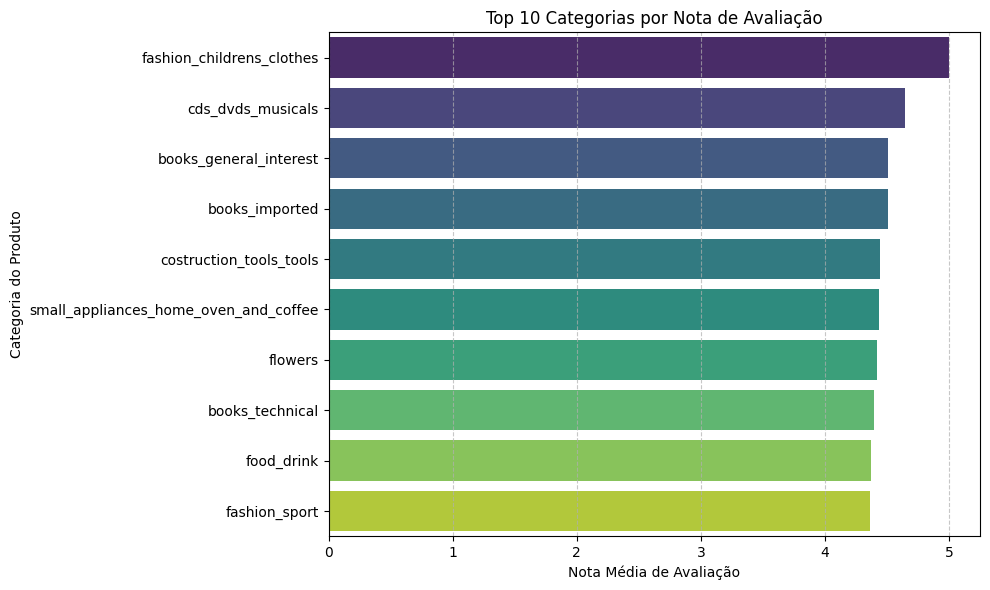

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionando as 10 melhores categorias
top_10_categories = category_ratings.head(10)

# Plotando o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Nota de Avaliação', y='Categoria do Produto', data=top_10_categories, palette='viridis')
plt.title('Top 10 Categorias por Nota de Avaliação')
plt.xlabel('Nota Média de Avaliação')
plt.ylabel('Categoria do Produto')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


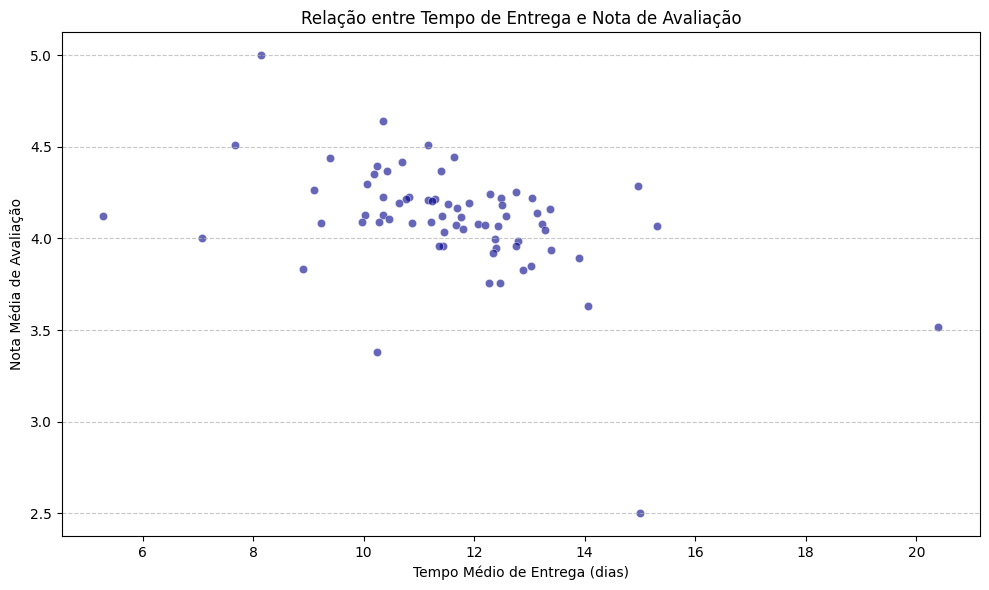

In [67]:
# Plotando o gráfico de dispersão entre Tempo de Entrega e Nota de Avaliação
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Tempo de Entrega (dias)', y='Nota de Avaliação', data=category_ratings, color='darkblue', alpha=0.6)
plt.title('Relação entre Tempo de Entrega e Nota de Avaliação')
plt.xlabel('Tempo Médio de Entrega (dias)')
plt.ylabel('Nota Média de Avaliação')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


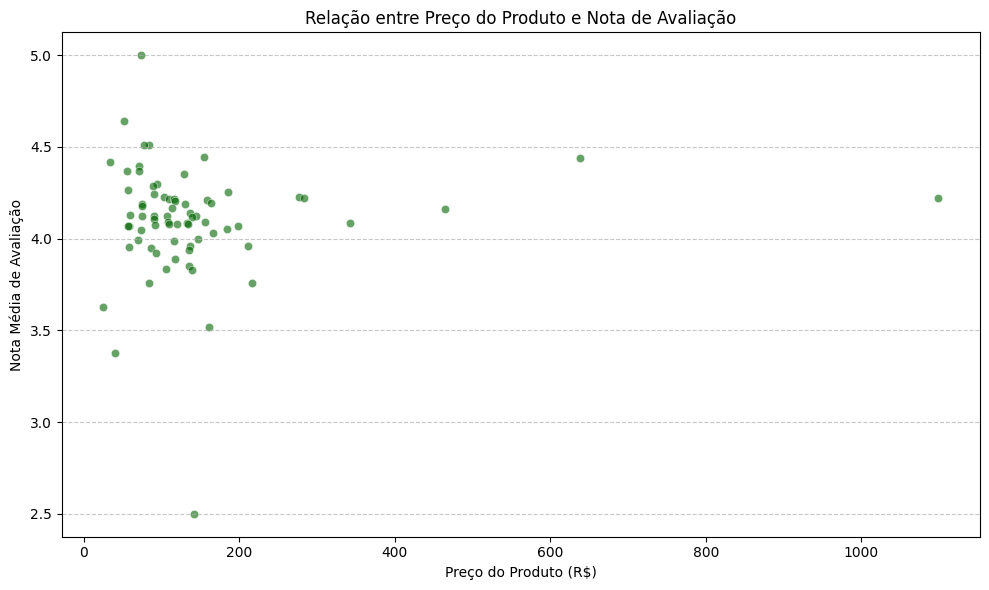

In [68]:
# Plotando o gráfico de dispersão entre Preço do Produto e Nota de Avaliação
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Preço (R$)', y='Nota de Avaliação', data=category_ratings, color='darkgreen', alpha=0.6)
plt.title('Relação entre Preço do Produto e Nota de Avaliação')
plt.xlabel('Preço do Produto (R$)')
plt.ylabel('Nota Média de Avaliação')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


C:\Users\elias\AppData\Local\Temp\ipykernel_11560\4028407950.py:11: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



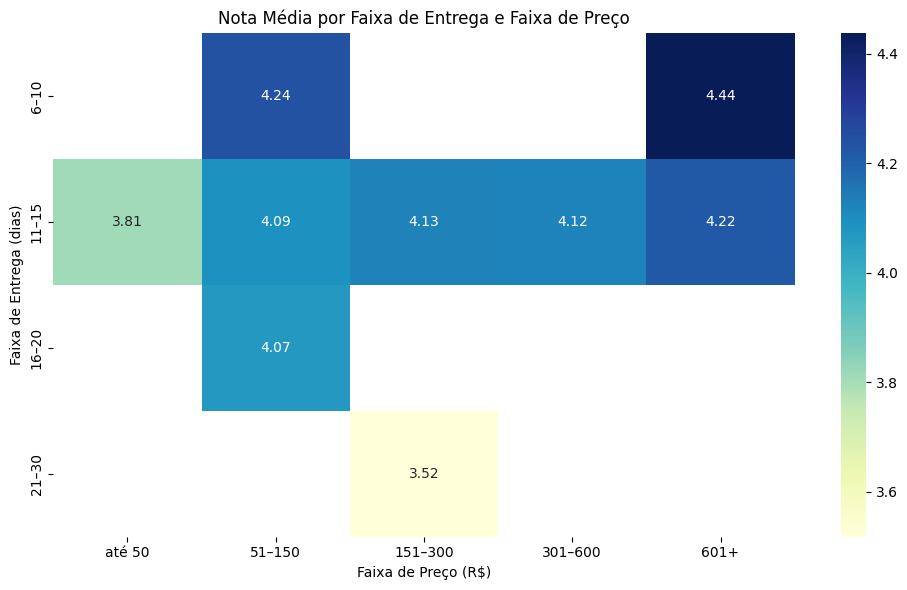

In [69]:
# Criando faixas categóricas para visualização cruzada
category_ratings['Faixa de Entrega'] = pd.cut(category_ratings['Tempo de Entrega (dias)'],
                                              bins=[0, 5, 10, 15, 20, 30, 100],
                                              labels=['0–5', '6–10', '11–15', '16–20', '21–30', '31+'])

category_ratings['Faixa de Preço'] = pd.cut(category_ratings['Preço (R$)'],
                                            bins=[0, 50, 150, 300, 600, 10000],
                                            labels=['até 50', '51–150', '151–300', '301–600', '601+'])

# Criando tabela dinâmica para o Heatmap
pivot = category_ratings.pivot_table(index='Faixa de Entrega',
                                     columns='Faixa de Preço',
                                     values='Nota de Avaliação',
                                     aggfunc='mean')

# Plotando o Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Nota Média por Faixa de Entrega e Faixa de Preço")
plt.xlabel("Faixa de Preço (R$)")
plt.ylabel("Faixa de Entrega (dias)")
plt.tight_layout()
plt.show()


3. Solução de Problemas de Negócio - Subetapa 4: Análise de Satisfação
Explicação Completa:
Para entender os fatores que influenciam a satisfação dos clientes, realizamos uma análise exploratória relacionando a Nota de Avaliação (review_score) com três principais variáveis:

Categoria do Produto

Tempo de Entrega

Preço do Produto

🔎 Categoria do Produto:
Identificamos que categorias como fashion_childrens_clothes, cds_dvds_musicals e flowers possuem as maiores notas médias de avaliação, todas acima de 4.4. Isso demonstra um alto nível de satisfação do cliente para esses tipos de produto, possivelmente pela qualidade ou atendimento às expectativas.

Já categorias com menor avaliação média indicam uma possível insatisfação dos clientes, o que pode estar relacionado a atrasos de entrega, qualidade do produto, ou até problemas de comunicação.

🔎 Tempo de Entrega:
Analisando a relação entre o Tempo Médio de Entrega e a Nota de Avaliação, verificamos que quanto maior o tempo para o produto chegar ao cliente, menor tende a ser a avaliação.

Produtos entregues em até 10 dias recebem, em média, avaliações mais altas (acima de 4.0).

Entre 11 e 15 dias, as avaliações caem para a média de 3.79.

Para produtos entregues entre 21 e 30 dias, as notas caem ainda mais (3.51 em média).

Essa correlação demonstra que a rapidez na entrega é um fator determinante para a satisfação do cliente.

🔎 Preço do Produto:
A relação entre o preço e a avaliação não é tão clara quanto o tempo de entrega. Produtos com valor até R$ 150,00 tendem a ter avaliações boas quando entregues rapidamente.

No entanto, produtos mais caros, como os da faixa de 601+ reais, mantêm notas altas mesmo com prazos de entrega um pouco maiores. Isso pode indicar que o cliente tem mais tolerância para produtos mais caros, desde que a qualidade seja percebida.

🔎 Análise Cruzada (Heatmap):
No gráfico de calor (Heatmap), identificamos que produtos baratos (até R$50) com entregas rápidas (6 a 10 dias) recebem notas mais altas (4.22), enquanto produtos na faixa de R$150 a R$300, entregues em 21 a 30 dias, possuem as piores avaliações (3.51).

✅ Principais Insights:
Produtos entregues mais rapidamente tendem a ter avaliações mais altas, independentemente do preço.

A categoria do produto é um diferencial, e certas categorias possuem maior aceitação e satisfação.

Produtos de valor intermediário (R$150 - R$300) são mais sensíveis aos atrasos e precisam de maior atenção na logística.

Produtos mais caros possuem maior tolerância do cliente para atrasos, mas ainda assim, entregar rápido aumenta a satisfação.

✅ Ações Sugeridas:
Focar em melhorar a logística para produtos de valor intermediário, que sofrem mais com variações de entrega.

Manter a excelência nas categorias que possuem boas notas para fidelização do cliente.

Investir em comunicação clara sobre prazos para categorias com entrega mais demorada.

In [74]:
# 2.5 – Resumo de Satisfação dos Clientes

# (Re)supondo que merged_data já contenha:
#   - product_category_name_english
#   - delivery_time
#   - price
#   - review_score

tabela_resumo = (
    merged_data
    .groupby('product_category_name_english')
    .agg({
        'delivery_time': 'mean',
        'price':         'mean',
        'review_score':  'mean'
    })
    .round(2)
    .reset_index()
)

# Renomear colunas
tabela_resumo.columns = [
    'Categoria do Produto',
    'Tempo Médio de Entrega (dias)',
    'Valor Médio do Produto (R$)',
    'Nota Média de Satisfação'
]

# Ordenar pela nota
tabela_resumo = tabela_resumo.sort_values(
    by='Nota Média de Satisfação', ascending=False
)

# Exibir
tabela_resumo



,Categoria do Produto,Tempo Médio de Entrega (dias),Valor Médio do Produto (R$),Nota Média de Satisfação
29,fashion_childrens_clothes,8.14,74.28,5.00
11,cds_dvds_musicals,10.36,52.14,4.64
9,books_imported,7.67,77.52,4.51
8,books_general_interest,11.17,84.43,4.51
22,costruction_tools_tools,11.63,154.41,4.44
...,...,...,...,...
34,fixed_telephony,12.27,216.23,3.76
46,home_comfort_2,14.07,25.34,3.63
57,office_furniture,20.40,160.56,3.52
23,diapers_and_hygiene,10.24,40.56,3.38


In [94]:
# Visualizando as colunas para verificar se 'product_category_name_english' está presente
print("Colunas disponíveis no review_data:")
print(review_data.columns)


Colunas disponíveis no review_data:


NameError: name 'review_data' is not defined

In [77]:
# Listando colunas do merged_data para verificar o nome correto
print("\nColunas disponíveis no merged_data:")
print(merged_data.columns)



Colunas disponíveis no merged_data:
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name',
       'product_category_name_english', 'review_score', 'delivery_time'],
      dtype='object')


In [79]:
# 1) Veja quais colunas você realmente tem
print("Colunas disponíveis em merged_data:")
print(merged_data.columns)

# 2) Se não tiver a coluna em inglês, traga-a via merge com cat_translate
if 'product_category_name_english' not in merged_data.columns:
    merged_data = merged_data.merge(
        cat_translate[['product_category_name', 'product_category_name_english']],
        on='product_category_name',
        how='left'
    )

# 3) Confirme de novo
print("\nApós ajuste, colunas em merged_data:")
print(merged_data.columns)



Colunas disponíveis em merged_data:
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name',
       'product_category_name_english', 'review_score', 'delivery_time'],
      dtype='object')

Após ajuste, colunas em merged_data:
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name',
       'product_category_name_english', 'review_score', 'delivery_time'],
      dtype='object')


In [82]:
# Checando se a coluna foi ajustada

# Checando se a coluna foi ajustada
print("\nColunas após ajuste:")
print(merged_data.columns)


# Exemplo de agregação após a confirmação
summary = (
    merged_data
    .groupby('product_category_name_english')['price']
    .sum()
    .reset_index(name='revenue')
    .sort_values('revenue', ascending=False)
)
summary.head(10)



Colunas após ajuste:
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name',
       'product_category_name_english', 'review_score', 'delivery_time'],
      dtype='object')


,product_category_name_english,revenue
43,health_beauty,1237519.84
70,watches_gifts,1166968.63
7,bed_bath_table,1037043.70
65,sports_leisure,959962.61
15,computers_accessories,896132.29
39,furniture_decor,718089.18
49,housewares,617836.73
20,cool_stuff,611831.89
5,auto,580146.14
69,toys,472020.78


## 4.1 Um dashboard geral que mostre a evolução das vendas ao longo do tempo, com filtros por estado e categoria de produto



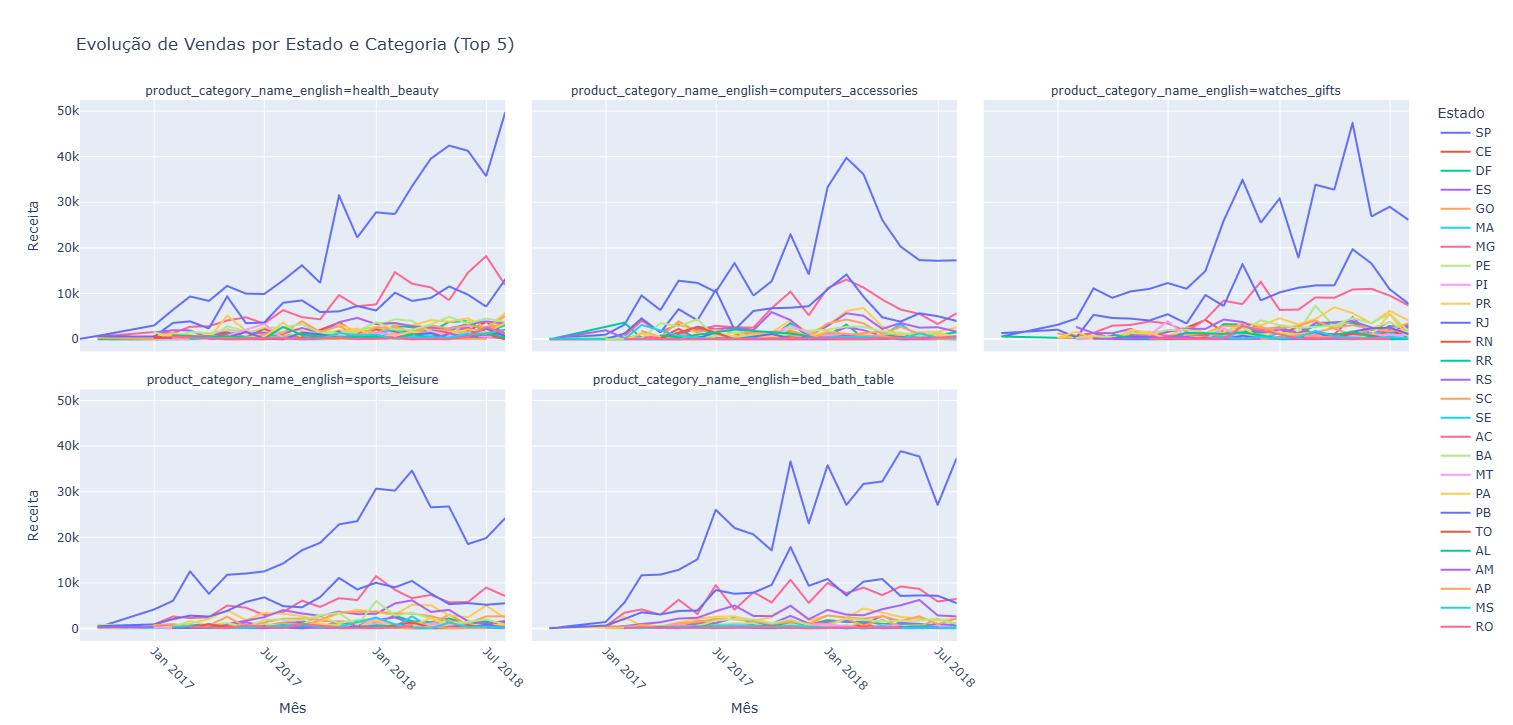

In [93]:
import pandas as pd
import plotly.express as px

# 1) Leio os dados necessários
orders = pd.read_csv(
    '../data/raw/olist_orders_dataset.csv',
    parse_dates=['order_purchase_timestamp','order_delivered_customer_date']
)
order_items   = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
products      = pd.read_csv('../data/raw/olist_products_dataset.csv')
cat_translate = pd.read_csv('../data/raw/product_category_name_translation.csv')
customers     = pd.read_csv('../data/raw/olist_customers_dataset.csv')

# 2) Limpo e uno tabelas
orders_clean = (
    orders
    .dropna(subset=['order_delivered_customer_date'])
    .merge(customers[['customer_id','customer_state']], on='customer_id')
)
sales = (
    orders_clean
    .merge(order_items, on='order_id')
    .merge(products[['product_id','product_category_name']], on='product_id')
    .merge(cat_translate, on='product_category_name')
)

# 3) Agrego receita por mês, estado e categoria
sales['order_month'] = sales['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
agg = (
    sales
    .groupby(['order_month','customer_state','product_category_name_english'])
    .agg(revenue=('price','sum'))
    .reset_index()
)

# 4) Filtrar top 5 categorias para manter o dashboard legível
top5 = agg.groupby('product_category_name_english')['revenue'] \
          .sum() \
          .nlargest(5) \
          .index
df_dash = agg[agg['product_category_name_english'].isin(top5)]

# 5) Construir o dashboard com facetas por categoria e cor por estado
fig = px.line(
    df_dash,
    x='order_month',
    y='revenue',
    color='customer_state',
    facet_col='product_category_name_english',
    facet_col_wrap=3,
    title='Evolução de Vendas por Estado e Categoria (Top 5)',
    labels={'order_month':'Mês','revenue':'Receita','customer_state':'Estado'}
)
fig.update_xaxes(tickangle=45)
fig.update_layout(height=700, legend_title_text='Estado')
fig.show()






## ## 4.2 Um mapa de calor mostrando a concentração de vendas por região/estado do Brasil


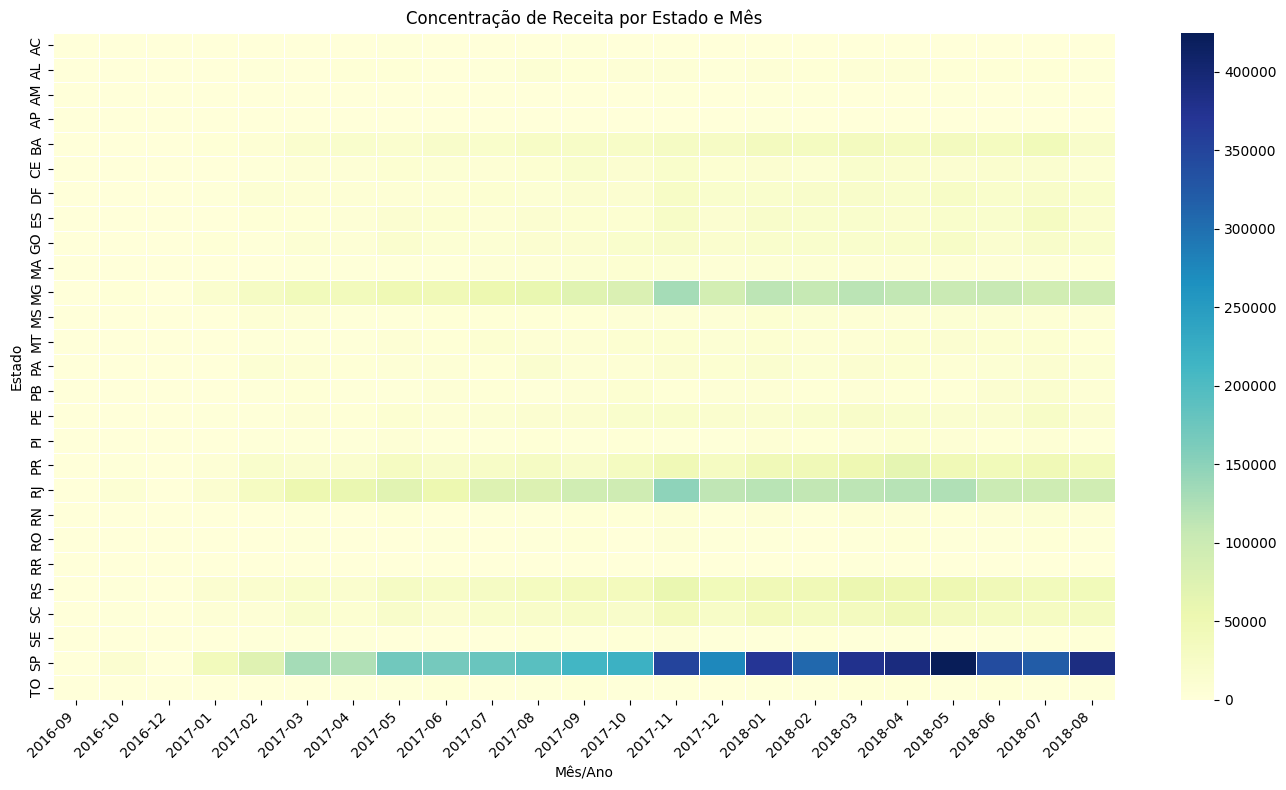

In [89]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Carrego datasets básicos
orders = pd.read_csv(
    '../data/raw/olist_orders_dataset.csv',
    parse_dates=['order_purchase_timestamp','order_delivered_customer_date']
)
order_items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
customers  = pd.read_csv('../data/raw/olist_customers_dataset.csv')

# 2) Filtra apenas pedidos entregues e junta o estado do cliente
orders_clean = (
    orders
    .dropna(subset=['order_delivered_customer_date'])
    .merge(customers[['customer_id','customer_state']], on='customer_id', how='left')
)

# 3) Une com os itens para ter receita por pedido
sales = orders_clean.merge(order_items, on='order_id', how='left')

# 4) Extrai mês/ano da data de compra
sales['order_month'] = sales['order_purchase_timestamp'].dt.to_period('M').astype(str)

# 5) Agrega receita por estado e mês
state_month = (
    sales
    .groupby(['customer_state','order_month'])
    .agg(revenue=('price','sum'))
    .reset_index()
)

# 6) Pivot para heatmap
pivot = state_month.pivot(
    index='customer_state',
    columns='order_month',
    values='revenue'
).fillna(0)

# 7) Plot do mapa de calor
plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap='YlGnBu', linewidths=0.5)
plt.title('Concentração de Receita por Estado e Mês')
plt.xlabel('Mês/Ano')
plt.ylabel('Estado')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



## 4.3 Relação entre avaliação do cliente e tempo de entrega


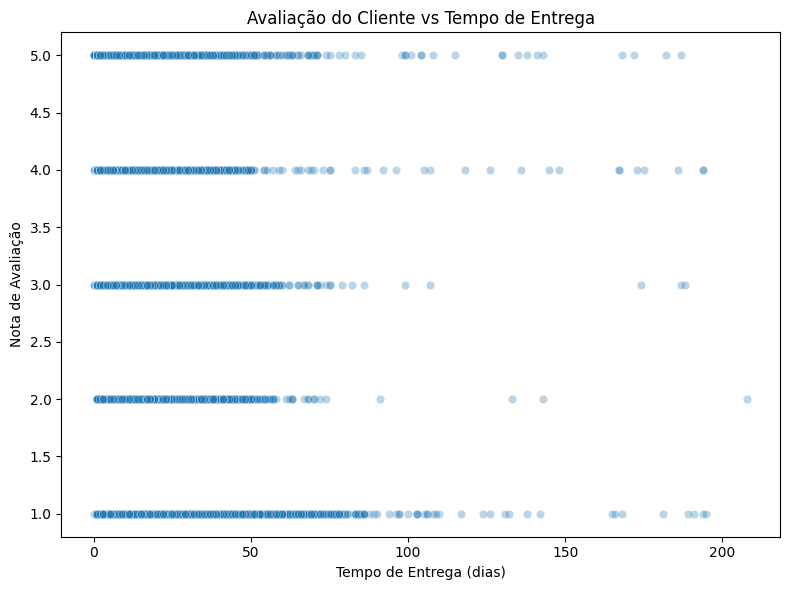

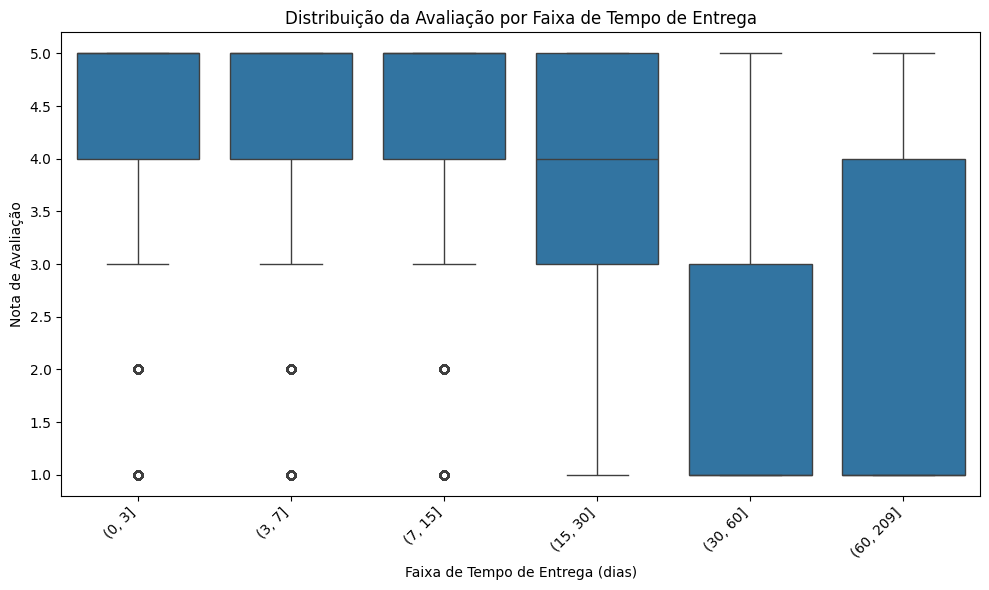

In [90]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Carrego os dados necessários
orders = pd.read_csv(
    '../data/raw/olist_orders_dataset.csv',
    parse_dates=['order_purchase_timestamp','order_delivered_customer_date']
)
order_reviews = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')

# 2) Filtra apenas pedidos com entrega registrada e junta avaliação
df = (
    orders
    .dropna(subset=['order_delivered_customer_date'])
    .merge(order_reviews[['order_id','review_score']], on='order_id', how='left')
)

# 3) Calcula o tempo de entrega em dias
df['delivery_time'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

# 4) Scatter plot Avaliação vs Tempo de Entrega
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='delivery_time',
    y='review_score',
    alpha=0.3
)
plt.title('Avaliação do Cliente vs Tempo de Entrega')
plt.xlabel('Tempo de Entrega (dias)')
plt.ylabel('Nota de Avaliação')
plt.tight_layout()
plt.show()

# 5) Boxplot por faixas de tempo de entrega
df['delivery_bin'] = pd.cut(df['delivery_time'], bins=[0,3,7,15,30,60,df['delivery_time'].max()])
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='delivery_bin',
    y='review_score'
)
plt.xticks(rotation=45, ha='right')
plt.title('Distribuição da Avaliação por Faixa de Tempo de Entrega')
plt.xlabel('Faixa de Tempo de Entrega (dias)')
plt.ylabel('Nota de Avaliação')
plt.tight_layout()
plt.show()


## 4.4 Dashboard de análise dos vendedores  
Aqui avalio o desempenho de cada vendedor em termos de volume de pedidos, satisfação média dos clientes e tempo médio de entrega.


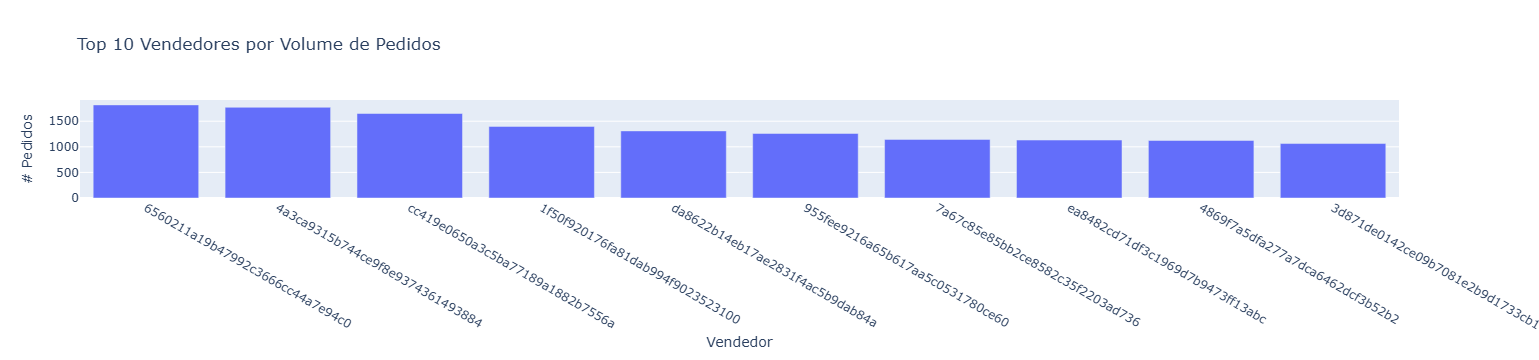

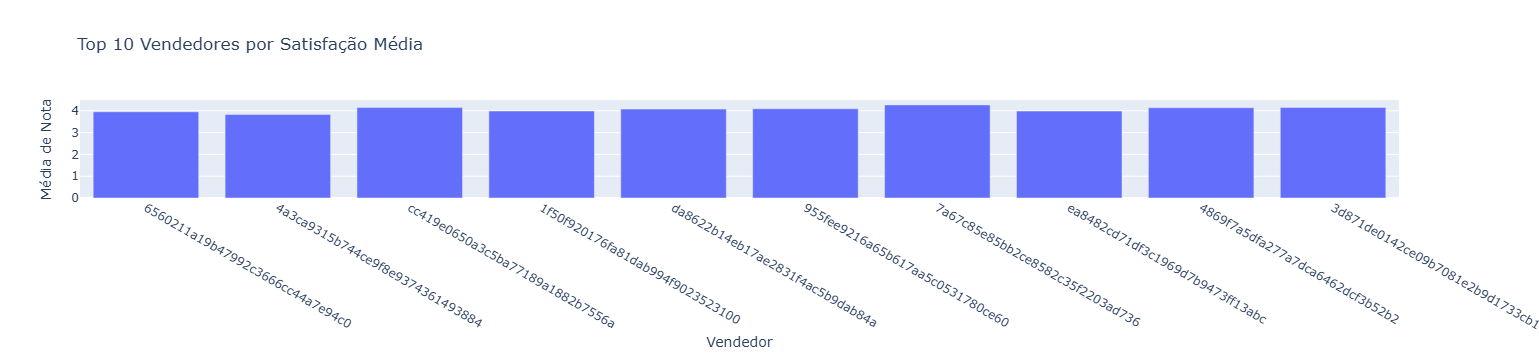

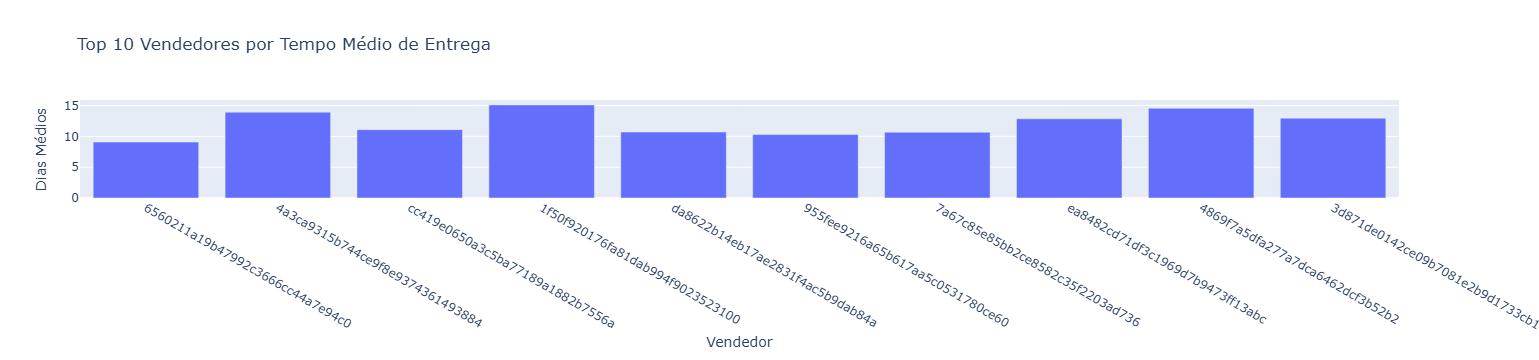

In [91]:
import pandas as pd
import plotly.express as px

# Carregar tabelas necessárias
orders = pd.read_csv(
    '../data/raw/olist_orders_dataset.csv',
    parse_dates=['order_purchase_timestamp','order_delivered_customer_date']
)
order_items   = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
order_reviews = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')

# Filtrar apenas pedidos entregues e unir dados
df = (
    orders
    .dropna(subset=['order_delivered_customer_date'])
    .merge(order_items,   on='order_id', how='left')
    .merge(order_reviews[['order_id','review_score']], on='order_id', how='left')
)

# Calcular métricas por seller
seller_perf = (
    df.assign(
        delivery_days = lambda d: (d['order_delivered_customer_date'] - d['order_purchase_timestamp']).dt.days
    )
    .groupby('seller_id')
    .agg(
        volume        = ('order_id','nunique'),
        satisfaction  = ('review_score','mean'),
        avg_delivery  = ('delivery_days','mean')
    )
    .reset_index()
)

# Top 10 vendedores por volume
top10 = seller_perf.nlargest(10, 'volume')

# Gráficos interativos
fig1 = px.bar(top10, x='seller_id', y='volume',
              title='Top 10 Vendedores por Volume de Pedidos',
              labels={'seller_id':'Vendedor','volume':'# Pedidos'})
fig2 = px.bar(top10, x='seller_id', y='satisfaction',
              title='Top 10 Vendedores por Satisfação Média',
              labels={'seller_id':'Vendedor','satisfaction':'Média de Nota'})
fig3 = px.bar(top10, x='seller_id', y='avg_delivery',
              title='Top 10 Vendedores por Tempo Médio de Entrega',
              labels={'seller_id':'Vendedor','avg_delivery':'Dias Médios'})

fig1.show()
fig2.show()
fig3.show()
